# Air Quality & Pollution Prediction in European Cities
## Data Loading, Cleaning, EDA, and Modeling

This notebook performs:
- dataset loading
- data cleaning
- missing value handling
- outlier treatment
- exploratory data analysis
- feature engineering
- multi-output regression modeling

The target pollutants are:
- PM2.5
- PM10
- NO2
- O3

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## Load the Dataset

The dataset is loaded using a robust parser configuration to avoid failure from malformed rows or encoding issues.

In [10]:
file_path = r"C:\Users\Rohit Reddy\OneDrive\Desktop\Data 602\ancona_data.csv"

df = pd.read_csv(
    file_path,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (417626, 19)


,Date,NO2,O3,PM10,PM2.5,Latitude,Longitude,station_name,Wind-Speed (U),Wind-Speed (V),Dewpoint Temp,Soil Temp,Total Percipitation,Vegitation (High),Vegitation (Low),Temp,Relative Humidity,code,id
0,2021-09-01 01:00:00,7.000000,53.000000,15.000000,4.000000,43.612386,13.510830,Ancona Citadella,-0.528286,-0.987673,63.563788,66.476667,0.0,3.184390,2.847654,66.075624,85.422435,IT1827A,26
1,2021-09-01 01:00:00,8.000000,NaN,9.000000,NaN,43.527982,13.246672,Jesi,-0.529657,-0.987282,64.894507,67.803820,0.0,3.179204,2.851910,67.392994,85.502078,IT0460A,23
2,2021-09-01 01:00:00,9.035176,49.232338,10.681684,7.700312,43.450000,13.250000,Ancona CAMS Station 11,-0.529798,-0.987225,65.123477,68.032686,0.0,3.176792,2.852830,67.622493,85.500013,ANCCAMS11,39
3,2021-09-01 01:00:00,10.292098,51.336113,10.310384,6.732396,43.550000,13.450000,Ancona CAMS Station 8,-0.528619,-0.987565,63.943511,66.855648,0.0,3.181947,2.849007,66.453195,85.435906,ANCCAMS08,36
4,2021-09-01 01:00:00,8.348963,39.351303,10.273862,7.066792,43.550000,13.150000,Ancona CAMS Station 5,-0.530069,-0.987179,65.208544,68.116622,0.0,3.179280,2.852743,67.701531,85.534001,ANCCAMS05,33


In [11]:
print("Columns:\n")
print(df.columns.tolist())

print("\nData types:\n")
print(df.dtypes)

print("\nMissing values before cleaning:\n")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Columns:

['Date', 'NO2', 'O3', 'PM10', 'PM2.5', 'Latitude', 'Longitude', 'station_name', 'Wind-Speed (U)', 'Wind-Speed (V)', 'Dewpoint Temp', 'Soil Temp', 'Total Percipitation', 'Vegitation (High)', 'Vegitation (Low)', 'Temp', 'Relative Humidity', 'code', 'id']

Data types:

Date                    object
NO2                    float64
O3                     float64
PM10                   float64
PM2.5                  float64
Latitude               float64
Longitude              float64
station_name            object
Wind-Speed (U)         float64
Wind-Speed (V)         float64
Dewpoint Temp          float64
Soil Temp              float64
Total Percipitation    float64
Vegitation (High)      float64
Vegitation (Low)       float64
Temp                   float64
Relative Humidity      float64
code                    object
id                       int64
dtype: object

Missing values before cleaning:

PM2.5                  45118
PM10                   27859
O3                     24803

## Standardize the Date Column

The dataset may contain either `Date` or `datetime`. This step detects the correct column and converts it to datetime format.

In [12]:
date_col = None

if "Date" in df.columns:
    date_col = "Date"
elif "datetime" in df.columns:
    date_col = "datetime"
else:
    raise ValueError("No date column found. Expected 'Date' or 'datetime'.")

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

print("Using date column:", date_col)
print("Invalid dates:", df[date_col].isnull().sum())

Using date column: Date
Invalid dates: 0


## Convert Important Columns to Numeric

Real-world environmental datasets often contain invalid strings inside numeric columns.  
This step forces such values to `NaN` so they can be safely handled later.

In [13]:
target_cols = ["PM2.5", "PM10", "NO2", "O3"]

candidate_numeric_cols = [
    "PM2.5", "PM10", "NO2", "O3",
    "Temp", "temperature",
    "Relative Humidity", "humidity",
    "wind_speed", "pressure",
    "CO", "SO2"
]

existing_numeric_cols = [col for col in candidate_numeric_cols if col in df.columns]

for col in existing_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Converted numeric columns:")
print(existing_numeric_cols)

Converted numeric columns:
['PM2.5', 'PM10', 'NO2', 'O3', 'Temp', 'Relative Humidity']


## Drop Rows with Missing Dates

Since date is essential for time-based analysis, rows with invalid dates are removed.

In [14]:
df = df.dropna(subset=[date_col]).copy()
print("Shape after dropping invalid dates:", df.shape)

Shape after dropping invalid dates: (417626, 19)


## Feature Engineering from Date

The following features are extracted:
- year
- month
- day
- day_of_week
- is_weekend
- season

In [15]:
df["year"] = df[date_col].dt.year
df["month"] = df[date_col].dt.month
df["day"] = df[date_col].dt.day
df["day_of_week"] = df[date_col].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

display(df[[date_col, "year", "month", "day", "day_of_week", "is_weekend", "season"]].head())

,Date,year,month,day,day_of_week,is_weekend,season
0,2021-09-01 01:00:00,2021,9,1,2,0,Autumn
1,2021-09-01 01:00:00,2021,9,1,2,0,Autumn
2,2021-09-01 01:00:00,2021,9,1,2,0,Autumn
3,2021-09-01 01:00:00,2021,9,1,2,0,Autumn
4,2021-09-01 01:00:00,2021,9,1,2,0,Autumn


## Handle Missing Values

A hybrid strategy is used:
- target pollutants: median imputation
- numeric variables: median imputation
- categorical variables: mode imputation
- time ordering preserved by sorting on date

In [16]:
# ensure targets exist
missing_targets = [col for col in target_cols if col not in df.columns]
if missing_targets:
    raise ValueError(f"Missing target columns: {missing_targets}")

# target columns
df[target_cols] = df[target_cols].fillna(df[target_cols].median())

# numeric columns
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_non_target = [col for col in numeric_cols_all if col not in target_cols]

for col in numeric_cols_non_target:
    df[col] = df[col].fillna(df[col].median())

# categorical columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# sort by date
df = df.sort_values(by=date_col).reset_index(drop=True)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## Remove Unrealistic Pollutant Values

Negative pollution values are not realistic, so they are removed or clipped.  
This step also reduces the effect of corrupted measurements.

In [17]:
for col in target_cols:
    df[col] = df[col].clip(lower=0)

display(df[target_cols].describe())

,PM2.5,PM10,NO2,O3
count,417626.000000,417626.000000,417626.000000,417626.000000
mean,12.831554,18.744066,12.780398,56.960599
std,7.437637,10.142313,9.381123,25.101710
min,0.000000,0.000000,0.000000,0.000000
25%,8.141800,12.091807,6.513096,39.696693
50%,11.193825,16.547325,10.320171,56.561120
75%,15.454091,23.000000,16.000000,73.336110
max,200.000000,249.000000,285.000000,162.000000


## Outlier Treatment Using IQR Capping

Instead of dropping too many rows, extreme values are capped using the IQR method.
This is safer for large environmental datasets.

In [18]:
for col in target_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = max(0, Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping completed.")
display(df[target_cols].describe())

Outlier capping completed.


,PM2.5,PM10,NO2,O3
count,417626.000000,417626.000000,417626.000000,417626.000000
mean,12.404666,18.305396,12.232532,56.944283
std,5.887172,8.478179,7.598421,25.054346
min,0.000000,0.000000,0.000000,0.000000
25%,8.141800,12.091807,6.513096,39.696693
50%,11.193825,16.547325,10.320171,56.561120
75%,15.454091,23.000000,16.000000,73.336110
max,26.422527,39.362289,30.230357,123.795236


## Final Data Check

In [19]:
print("Final shape:", df.shape)
print("\nRemaining missing values:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

display(df.head())

Final shape: (417626, 25)

Remaining missing values:

Series([], dtype: int64)


,Date,NO2,O3,PM10,PM2.5,Latitude,Longitude,station_name,Wind-Speed (U),Wind-Speed (V),...,Temp,Relative Humidity,code,id,year,month,day,day_of_week,is_weekend,season
0,2021-09-01 01:00:00,7.000000,53.000000,15.000000,4.000000,43.612386,13.510830,Ancona Citadella,-0.528286,-0.987673,...,66.075624,85.422435,IT1827A,26,2021,9,1,2,0,Autumn
1,2021-09-01 01:00:00,9.635486,57.942540,10.488986,6.201891,43.650000,13.350000,Ancona CAMS Station 2,-0.528980,-0.987489,...,66.663000,85.472744,ANCCAMS02,30,2021,9,1,2,0,Autumn
2,2021-09-01 01:00:00,25.000000,13.000000,18.000000,8.000000,43.599523,13.342312,Chiarvalle,-0.529081,-0.987451,...,66.808977,85.472984,IT0459A,22,2021,9,1,2,0,Autumn
3,2021-09-01 01:00:00,7.454304,58.000107,8.418634,5.803703,43.650000,13.450000,Ancona CAMS Station 3,-0.528536,-0.987612,...,66.266151,85.443320,ANCCAMS03,31,2021,9,1,2,0,Autumn
4,2021-09-01 01:00:00,10.455807,36.120407,10.193969,7.274157,43.550000,13.250000,Ancona CAMS Station 6,-0.529598,-0.987302,...,67.314415,85.501234,ANCCAMS06,34,2021,9,1,2,0,Autumn


## Summary Statistics

In [20]:
display(df.describe(include="all"))

,Date,NO2,O3,PM10,PM2.5,Latitude,Longitude,station_name,Wind-Speed (U),Wind-Speed (V),...,Temp,Relative Humidity,code,id,year,month,day,day_of_week,is_weekend,season
count,417626,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000,417626,417626.000000,417626.000000,...,417626.000000,417626.000000,417626,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000,417626.000000,417626
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22,NaN,NaN,...,NaN,NaN,22,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ancona Citadella,NaN,NaN,...,NaN,NaN,IT1827A,NaN,NaN,NaN,NaN,NaN,NaN,Autumn
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18983,NaN,NaN,...,NaN,NaN,18983,NaN,NaN,NaN,NaN,NaN,NaN,128282
mean,2022-10-01 11:59:59.999999744,12.232532,56.944283,18.305396,12.404666,43.567772,13.363402,NaN,-0.112081,-0.203619,...,55.232497,75.301643,NaN,34.636364,2022.230153,6.755887,15.723911,3.000053,0.285729,NaN
min,2021-09-01 01:00:00,0.000000,0.000000,0.000000,0.000000,43.450000,13.150000,NaN,-3.877032,-3.671453,...,10.109338,12.943158,NaN,22.000000,2021.000000,1.000000,1.000000,0.000000,0.000000,NaN
25%,2022-03-17 18:00:00,6.513096,39.696693,12.091807,8.141800,43.527982,13.250000,NaN,-0.735605,-0.996508,...,52.015683,62.288855,NaN,27.000000,2022.000000,4.000000,8.000000,1.000000,0.000000,NaN
50%,2022-10-01 12:00:00,10.320171,56.561120,16.547325,11.193825,43.574761,13.361060,NaN,-0.368986,-0.360379,...,60.127705,79.907559,NaN,32.500000,2022.000000,7.000000,16.000000,3.000000,0.000000,NaN
75%,2023-04-17 06:00:00,16.000000,73.336110,23.000000,15.454091,43.637500,13.450000,NaN,0.456399,0.529858,...,66.983502,90.889160,NaN,38.000000,2023.000000,10.000000,23.000000,5.000000,1.000000,NaN
max,2023-10-31 23:00:00,30.230357,123.795236,39.362289,26.422527,43.650000,13.550000,NaN,3.617407,4.307326,...,88.419472,99.996023,NaN,90.000000,2023.000000,12.000000,31.000000,6.000000,1.000000,NaN


## Distribution of Target Pollutants

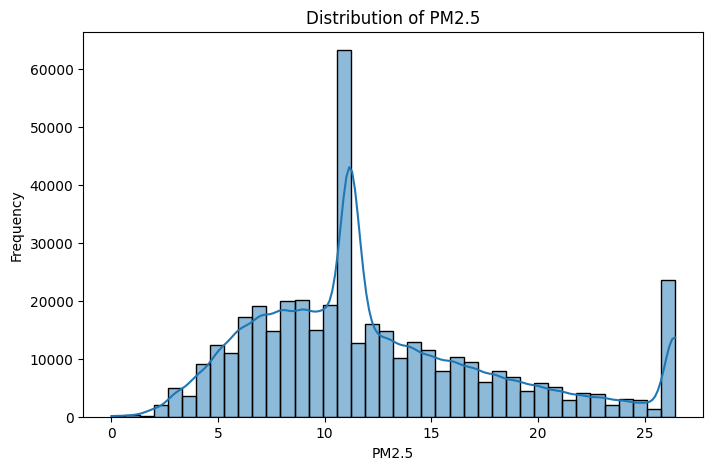

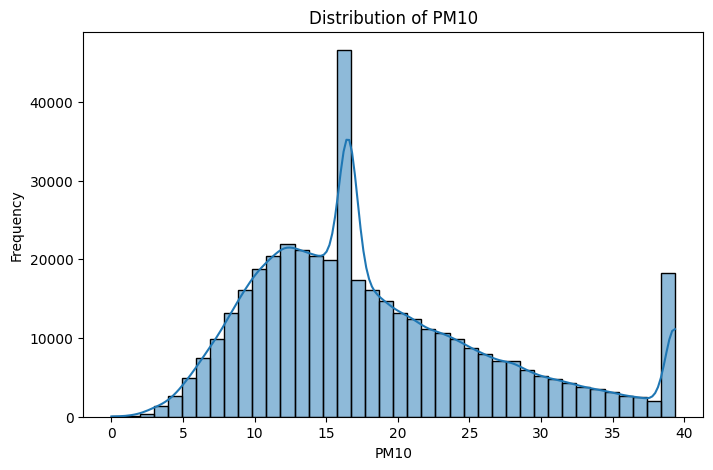

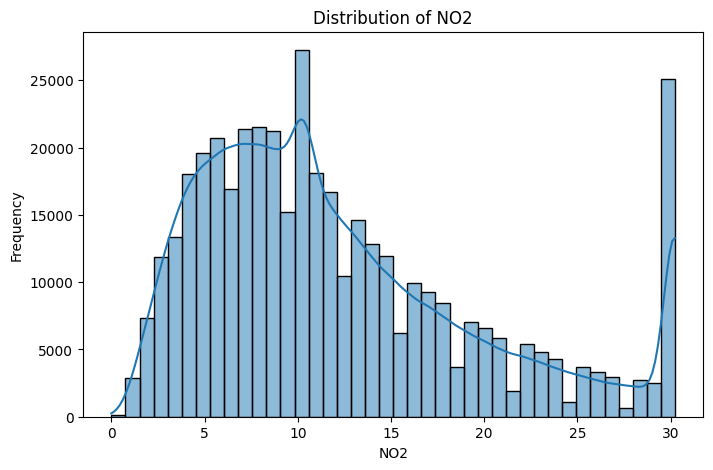

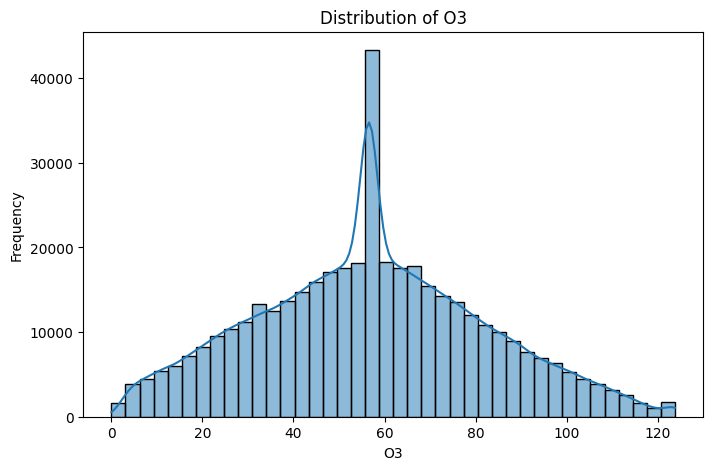

In [21]:
for col in target_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## Correlation Heatmap

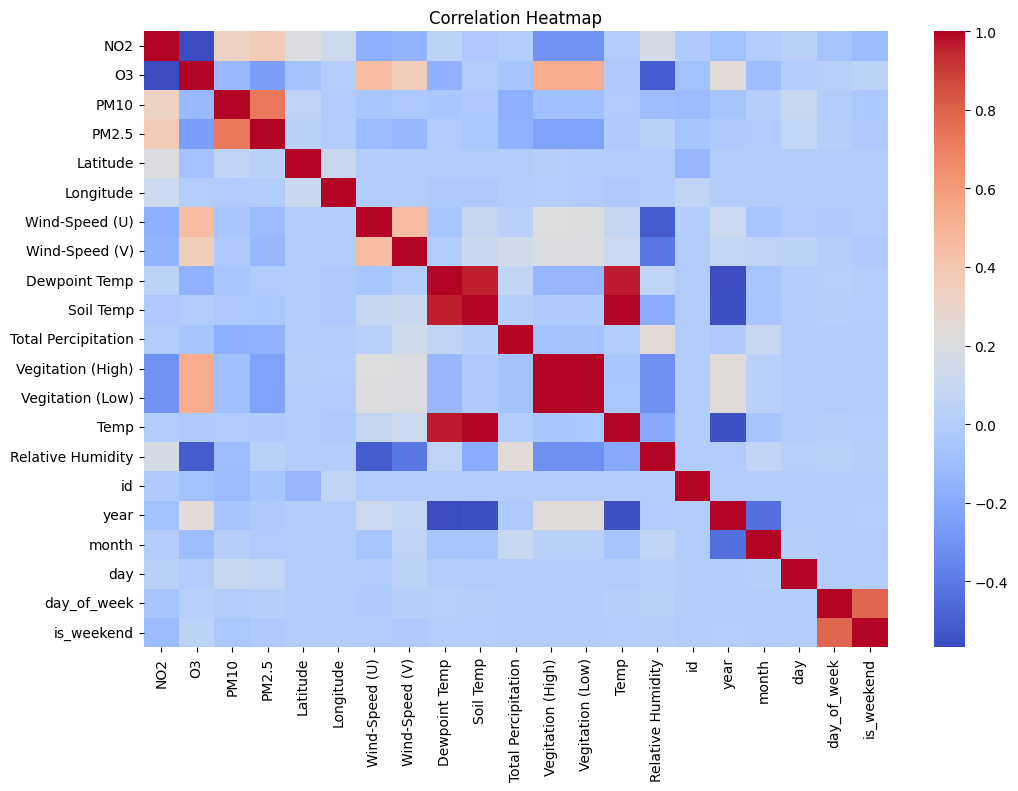

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Monthly Average Pollutant Levels

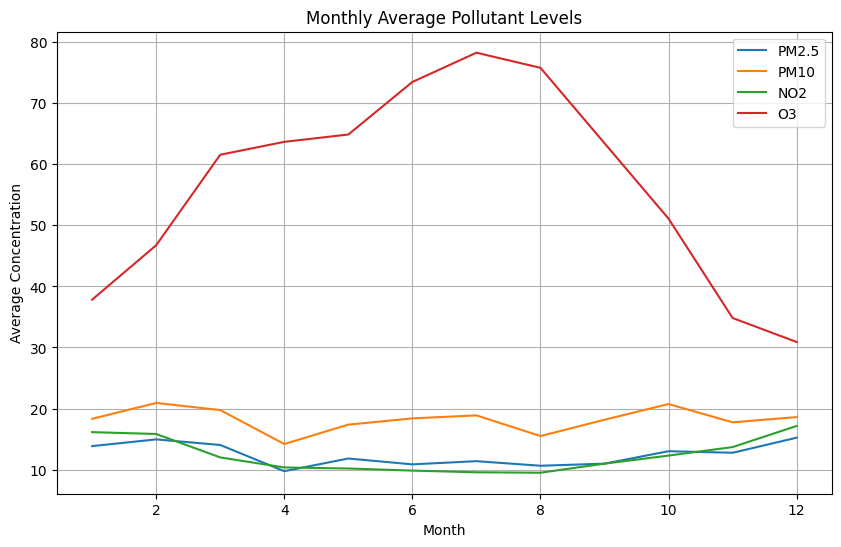

In [23]:
monthly_avg = df.groupby("month")[target_cols].mean()

monthly_avg.plot(figsize=(10, 6))
plt.title("Monthly Average Pollutant Levels")
plt.xlabel("Month")
plt.ylabel("Average Concentration")
plt.grid(True)
plt.show()

## Yearly Average Pollutant Levels

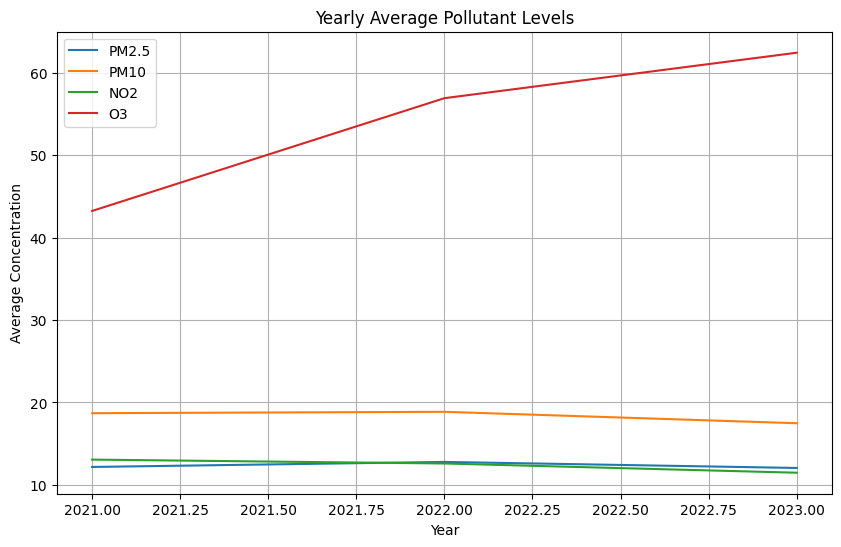

In [24]:
yearly_avg = df.groupby("year")[target_cols].mean()

yearly_avg.plot(figsize=(10, 6))
plt.title("Yearly Average Pollutant Levels")
plt.xlabel("Year")
plt.ylabel("Average Concentration")
plt.grid(True)
plt.show()

## Weather vs Pollution

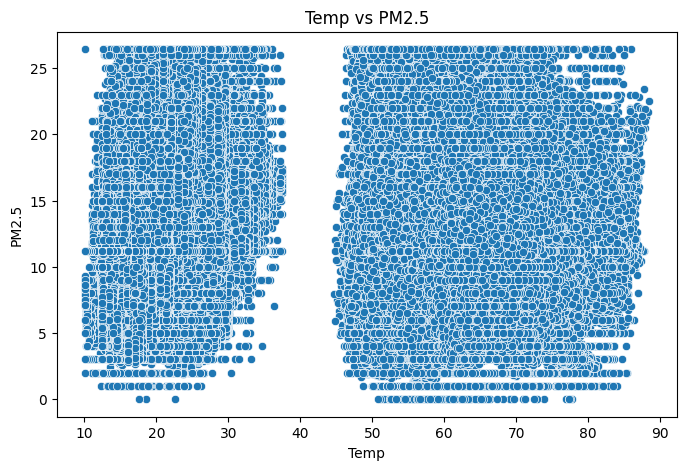

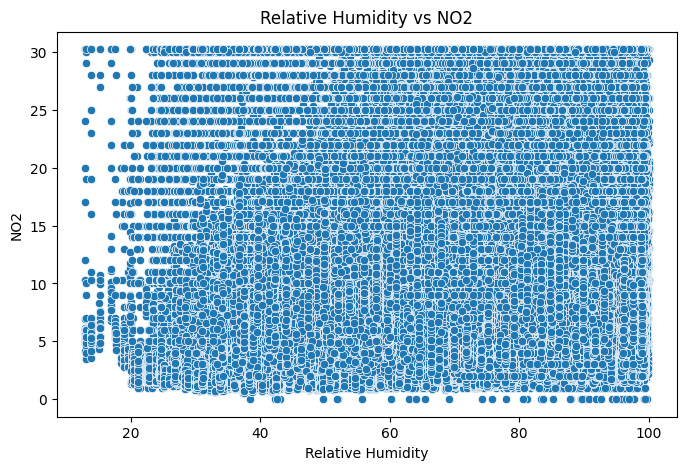

In [25]:
temp_col = "Temp" if "Temp" in df.columns else ("temperature" if "temperature" in df.columns else None)
humidity_col = "Relative Humidity" if "Relative Humidity" in df.columns else ("humidity" if "humidity" in df.columns else None)

if temp_col is not None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[temp_col], y=df["PM2.5"])
    plt.title(f"{temp_col} vs PM2.5")
    plt.xlabel(temp_col)
    plt.ylabel("PM2.5")
    plt.show()
else:
    print("Temperature column not found.")

if humidity_col is not None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[humidity_col], y=df["NO2"])
    plt.title(f"{humidity_col} vs NO2")
    plt.xlabel(humidity_col)
    plt.ylabel("NO2")
    plt.show()
else:
    print("Humidity column not found.")

## Boxplots for Pollutants

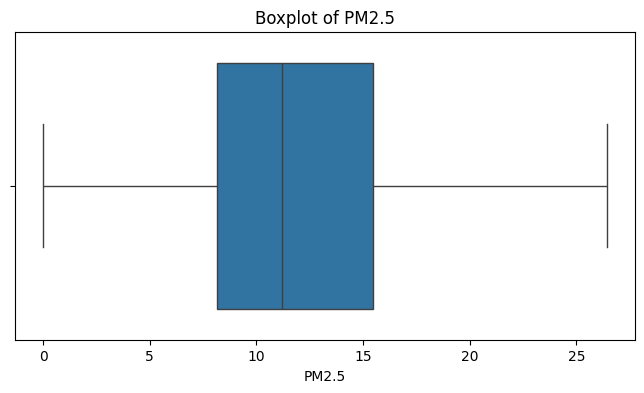

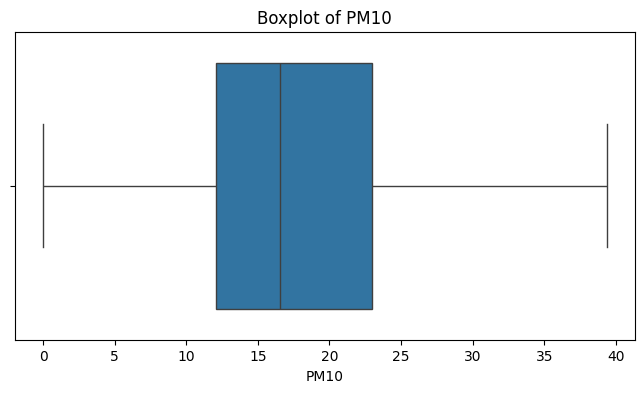

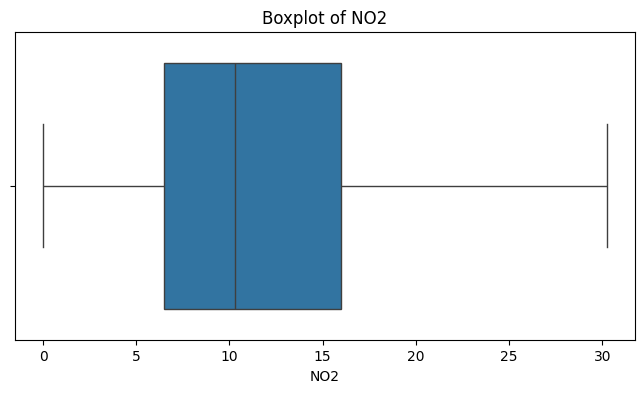

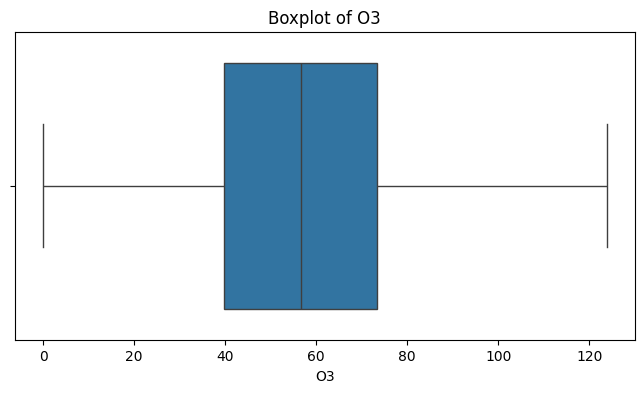

In [26]:
for col in target_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Top Stations by Average PM2.5

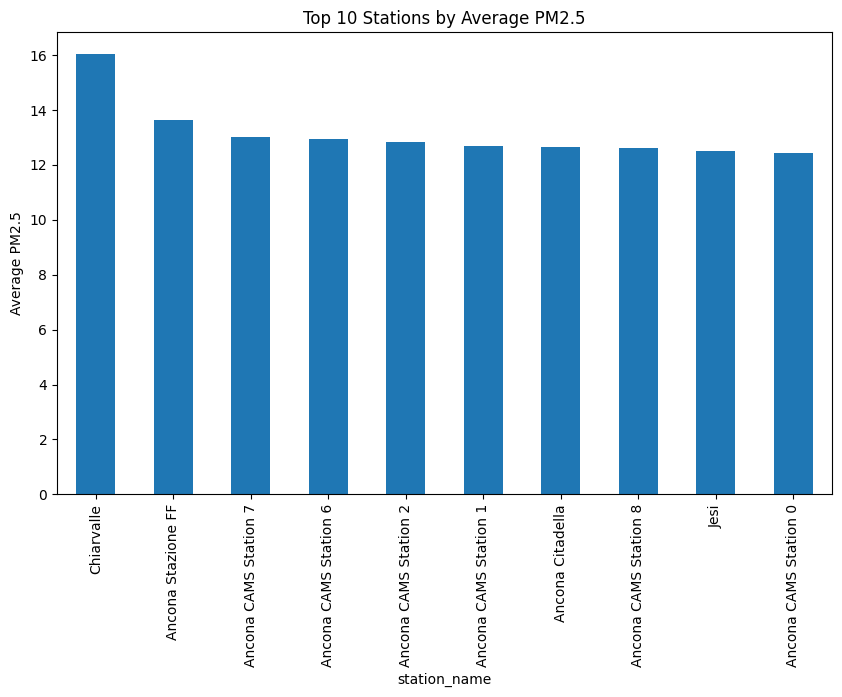

In [27]:
if "station_name" in df.columns:
    top_pm25 = df.groupby("station_name")["PM2.5"].mean().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    top_pm25.plot(kind="bar")
    plt.title("Top 10 Stations by Average PM2.5")
    plt.ylabel("Average PM2.5")
    plt.show()
else:
    print("Column 'station_name' not found. Skipping this plot.")

## Pairplot of Pollutants

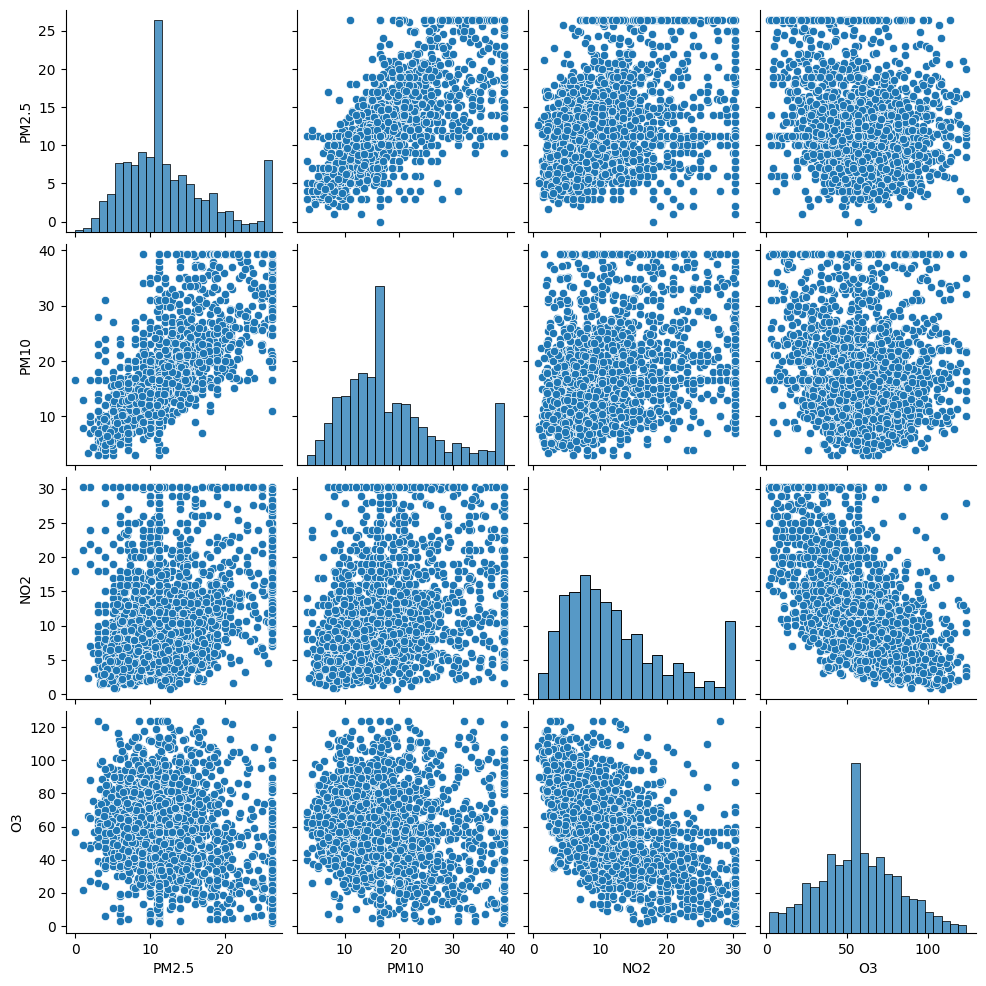

In [28]:
sample_for_pairplot = df[target_cols].dropna().sample(min(2000, len(df)), random_state=42)
sns.pairplot(sample_for_pairplot)
plt.show()

## Feature Selection for PM2.5

In [29]:
from sklearn.feature_selection import SelectKBest, f_regression

feature_candidates = []
for col in ["PM10", "NO2", "O3", "Temp", "temperature", "Relative Humidity", "humidity", "wind_speed", "pressure", "CO", "SO2"]:
    if col in df.columns:
        feature_candidates.append(col)

X_fs = df[feature_candidates].copy()
X_fs = X_fs.apply(pd.to_numeric, errors="coerce")
X_fs = X_fs.fillna(X_fs.median())

y_fs = df["PM2.5"]

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X_fs, y_fs)

scores = pd.DataFrame({
    "Feature": X_fs.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

display(scores)

,Feature,Score
0,PM10,466567.939534
1,NO2,69910.245308
2,O3,29257.949775
4,Relative Humidity,218.437914
3,Temp,133.450625


## Prepare Features for Machine Learning

In [30]:
feature_candidates = [
    "city",
    "station_name",
    "CO",
    "SO2",
    "Temp",
    "temperature",
    "Relative Humidity",
    "humidity",
    "wind_speed",
    "pressure",
    "year",
    "month",
    "day",
    "day_of_week",
    "is_weekend",
    "season"
]

feature_cols = [col for col in feature_candidates if col in df.columns]

X = df[feature_cols].copy()
y = df[target_cols].copy()

print("Feature columns used:")
print(feature_cols)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns used:
['station_name', 'Temp', 'Relative Humidity', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'season']

X shape: (417626, 9)
y shape: (417626, 4)


## Preprocessing Pipeline

In [31]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Temp', 'Relative Humidity', 'year', 'month', 'day', 'day_of_week', 'is_weekend']
Categorical features: ['station_name', 'season']


## Train-Test Split

In [32]:
# Keep only needed columns
target_cols = ["PM2.5", "PM10", "NO2", "O3"]

feature_candidates = [
    "CO", "SO2",
    "Temp", "temperature",
    "Relative Humidity", "humidity",
    "wind_speed", "pressure",
    "year", "month", "day", "day_of_week", "is_weekend"
]

feature_cols = [col for col in feature_candidates if col in df.columns]

# Create smaller modeling dataframe
model_df = df[feature_cols + target_cols].copy()

# Drop remaining missing rows just for modeling
model_df = model_df.dropna()

# Optional: sample rows if dataset is too large
if len(model_df) > 200000:
    model_df = model_df.sample(n=200000, random_state=42)

print("Modeling dataframe shape:", model_df.shape)
display(model_df.head())

Modeling dataframe shape: (200000, 11)


,Temp,Relative Humidity,year,month,day,day_of_week,is_weekend,PM2.5,PM10,NO2,O3
245308,62.729056,95.313327,2022,12,9,4,0,13.276945,16.083715,15.606135,37.967743
255240,60.593381,81.128378,2022,12,28,2,0,23.332674,23.477383,14.492118,20.122683
285799,54.258551,96.675475,2023,2,24,4,0,26.422527,31.847408,24.501873,22.595621
229745,59.206069,98.462825,2022,11,10,3,0,10.000000,16.547325,25.000000,9.000000
357800,30.929841,51.945984,2023,7,10,0,0,16.000000,39.000000,6.000000,99.000000


In [33]:
X = model_df[feature_cols]
y = model_df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200000, 7)
y shape: (200000, 4)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (160000, 7)
X_test : (40000, 7)
y_train: (160000, 4)
y_test : (40000, 4)


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [36]:
baseline_model = Pipeline(steps=[
    ("preprocess", numeric_pipeline),
    ("model", MultiOutputRegressor(LinearRegression()))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

In [37]:
rf_model = Pipeline(steps=[
    ("preprocess", numeric_pipeline),
    ("model", MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for i, target in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:, i], rf_preds[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], rf_preds[:, i]))
    r2 = r2_score(y_test.iloc[:, i], rf_preds[:, i])
    results.append([target, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Pollutant", "MAE", "RMSE", "R2 Score"])
display(results_df)

,Pollutant,MAE,RMSE,R2 Score
0,PM2.5,2.825482,3.786970,0.579812
1,PM10,4.471848,6.064105,0.486066
2,NO2,4.826075,6.342623,0.303592
3,O3,12.373364,16.201809,0.579949


In [39]:
results = []

for i, target in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:, i], rf_preds[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], rf_preds[:, i]))
    r2 = r2_score(y_test.iloc[:, i], rf_preds[:, i])

    results.append([target, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Pollutant", "MAE", "RMSE", "R2 Score"])
display(results_df)

,Pollutant,MAE,RMSE,R2 Score
0,PM2.5,2.825482,3.786970,0.579812
1,PM10,4.471848,6.064105,0.486066
2,NO2,4.826075,6.342623,0.303592
3,O3,12.373364,16.201809,0.579949


## Actual vs Predicted Plots

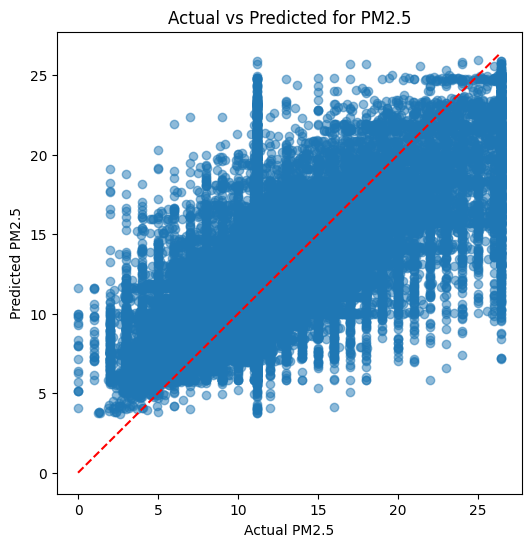

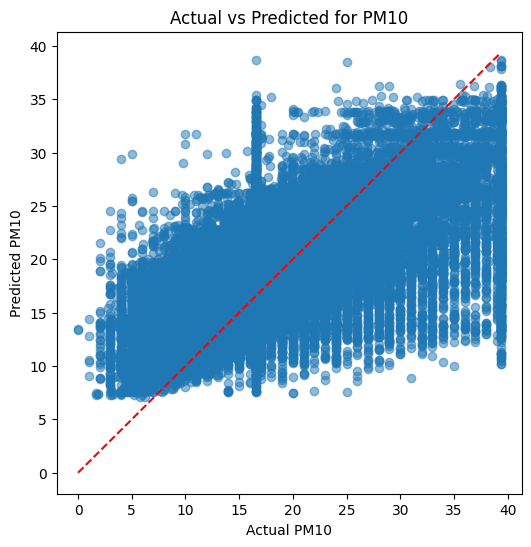

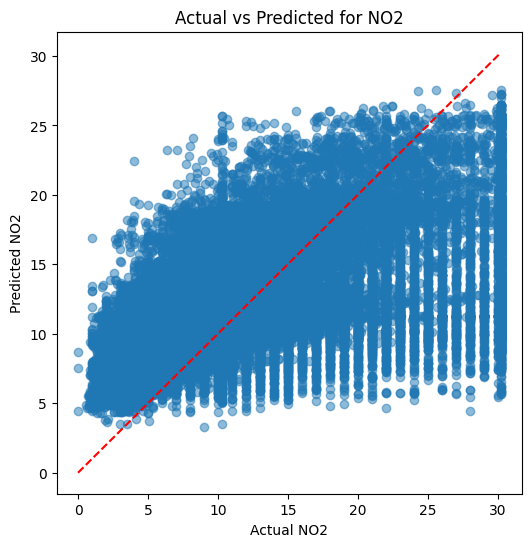

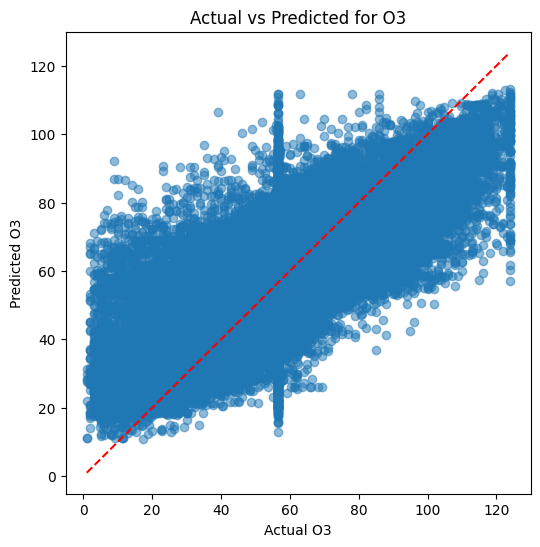

In [40]:
for i, target in enumerate(target_cols):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test.iloc[:, i], rf_preds[:, i], alpha=0.5)
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"Actual vs Predicted for {target}")

    min_val = min(y_test.iloc[:, i].min(), rf_preds[:, i].min())
    max_val = max(y_test.iloc[:, i].max(), rf_preds[:, i].max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--")
    plt.show()

## Save the Final Model

In [41]:
joblib.dump(rf_model, "air_quality_multioutput_model.pkl")
print("Model saved as air_quality_multioutput_model.pkl")

Model saved as air_quality_multioutput_model.pkl


## Sample Prediction

In [42]:
sample_input = {}

for col in feature_cols:
    if col in X.select_dtypes(include=[np.number]).columns:
        sample_input[col] = [X[col].median()]
    else:
        sample_input[col] = [X[col].mode()[0]]

sample_df = pd.DataFrame(sample_input)
sample_pred = rf_model.predict(sample_df)

prediction_df = pd.DataFrame(sample_pred, columns=target_cols)

display(sample_df)
display(prediction_df)

,Temp,Relative Humidity,year,month,day,day_of_week,is_weekend
0,60.147162,79.826759,2022.0,7.0,16.0,3.0,0.0


,PM2.5,PM10,NO2,O3
0,10.37571,13.736873,11.248276,59.240024


## Conclusion

This notebook built a complete workflow for air quality prediction:
- cleaned malformed and missing data
- engineered time-based features
- explored pollutant trends
- trained multi-output machine learning models
- evaluated predictions for PM2.5, PM10, NO2, and O3

In [43]:
import joblib

joblib.dump(rf_model, "air_quality_multioutput_model.pkl")
print("Model saved successfully!")

Model saved successfully!
